In [1]:
# %%
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 11

Imports core libraries for data handling, clustering, and visualization, and sets plotting style defaults.

## Load processed data

In [2]:
encoded_df = pd.read_csv('../data/student_dropout_processed.csv')
encoded_df.head()

,gender,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,...,ses_score,support_index,commute_burden,financial_pressure,academic_risk,risk_score,weighted_risk_score,normalized_risk_score,high_risk_student,risk_group
0,0,2,1,1,5,0,3,1,0,2,...,4,5,2,-1,-2,1,0.2,0.500000,0,Low
1,1,2,2,1,5,0,3,1,0,1,...,4,5,3,-1,-1,2,0.4,1.000000,0,Low
2,0,2,2,1,5,2,3,1,0,1,...,4,5,3,-1,1,5,1.4,2.666667,1,High
3,0,2,2,1,5,0,1,1,0,1,...,2,3,3,-1,-1,2,0.4,1.000000,0,Low
4,1,2,1,1,5,0,1,1,0,2,...,2,3,2,-1,-2,1,0.2,0.500000,0,Low


## Feature Selection

### For clustering

### Supervised Clustering (Target-Informed)

Below we add a target-informed feature (target encoding) for supervised clustering. This makes clusters reflect the dropout outcome, so interpret it as **supervised segmentation**, not pure unsupervised discovery.

In [3]:
cluster_features = [
    'attendance_quality',
    'engagement_score',
    'ses_score',
    'support_index',
    'commute_burden',
    'weighted_risk_score'
]

Defines the feature set for clustering, excluding `weighted_risk_score` to avoid leakage from the dropout target.

### For prediction

In [4]:
prediction_features = [
    'attendance_quality',
    'engagement_score',
    'ses_score',
    'support_index',
    'commute_burden'
]

Defines prediction features and excludes `weighted_risk_score` to reduce leakage risk.

to avoid leakage.

The weighted risk score was excluded from predictive modeling because it was partially derived from dropout-related indicators, which could introduce target leakage and artificially inflate model performance.

## Clustering Student's Group

We are going to GROUP students into low risk, medium risk, and high risk using KMeans.

In [5]:
X_cluster = encoded_df[cluster_features]

X_cluster.head()

,attendance_quality,engagement_score,ses_score,support_index,commute_burden,weighted_risk_score
0,5,7,4,5,2,0.2
1,5,6,4,5,3,0.4
2,3,4,4,5,3,1.4
3,5,6,2,3,3,0.4
4,5,7,2,3,2,0.2


Builds the clustering matrix from selected features and previews the data.

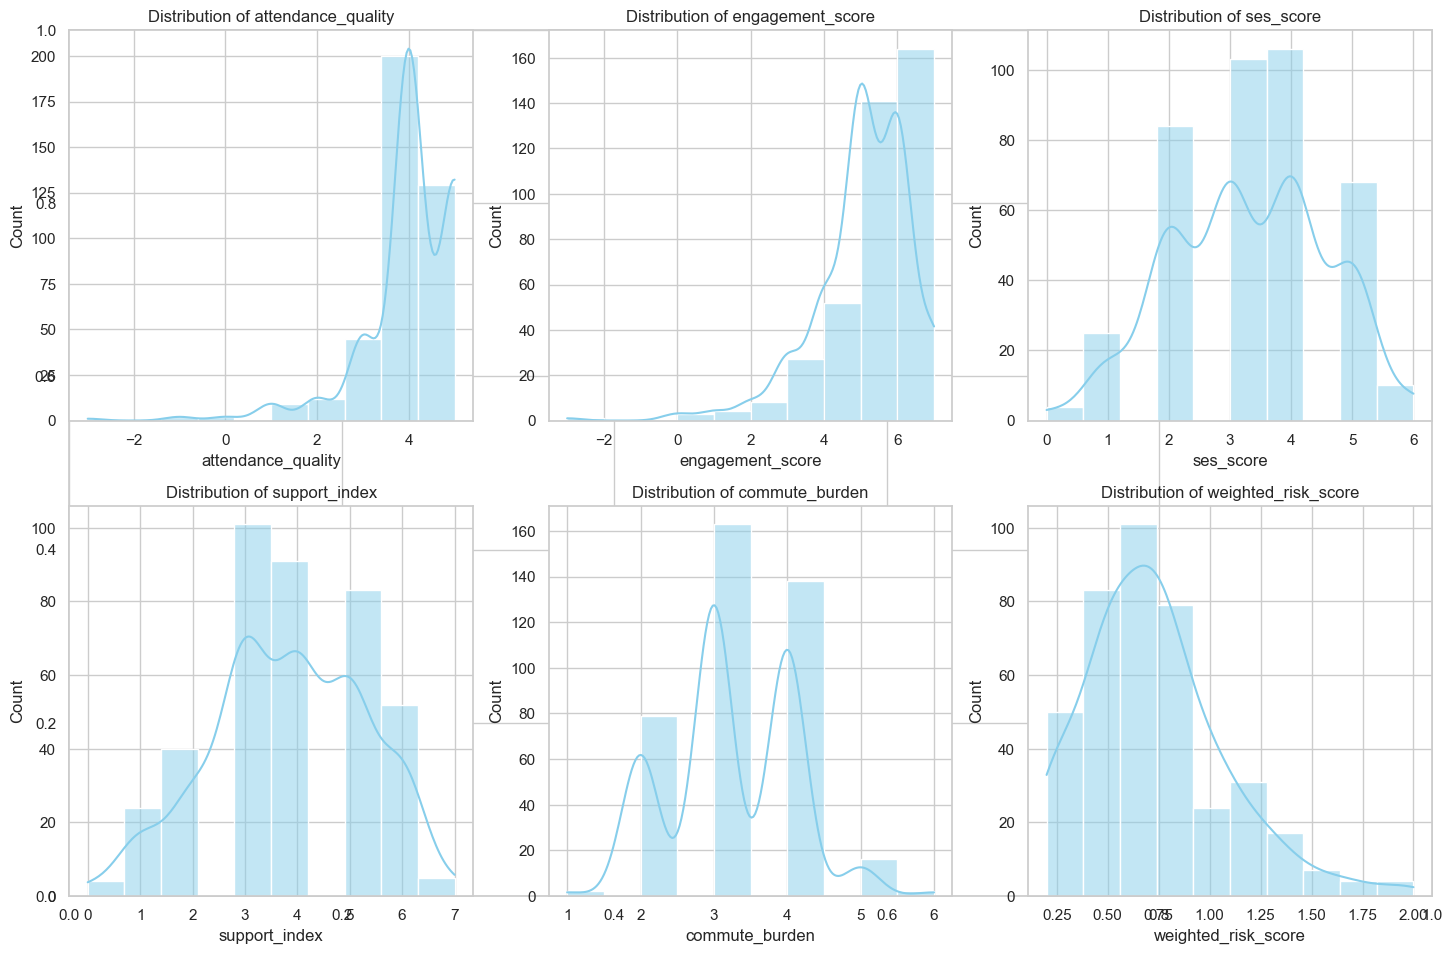

In [6]:
plt.subplots(figsize=(15,10))
for feature in cluster_features:
    plt.subplot(2, 3, cluster_features.index(feature) + 1)
    sns.histplot(encoded_df[feature], kde=True, bins=10, color='skyblue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

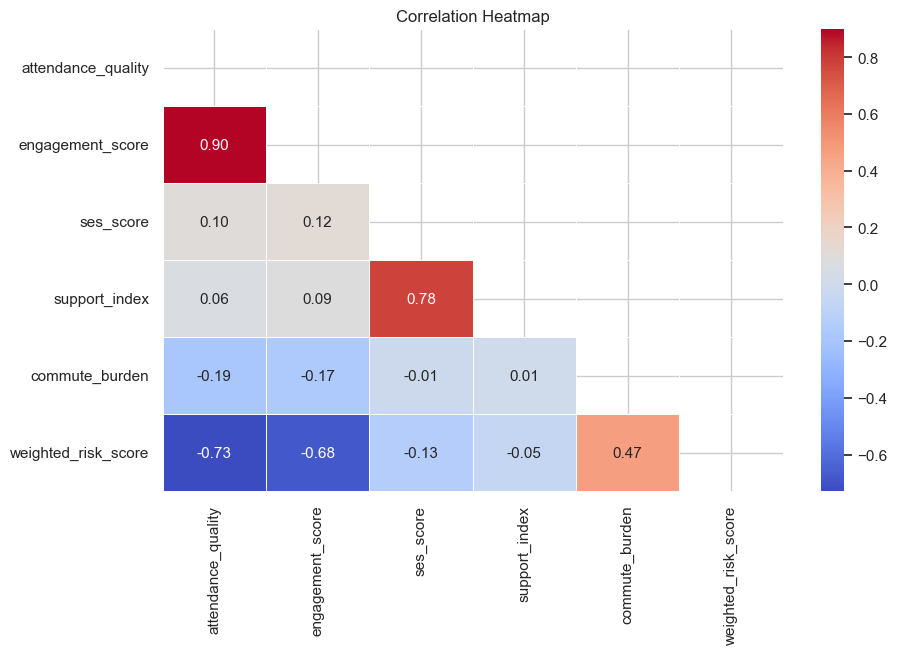

In [7]:
plt.figure(figsize=(10,6))

mask = np.triu(
    np.ones_like(X_cluster.corr(), dtype=bool)
)

sns.heatmap(
    X_cluster.corr(),
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Examines correlations among clustering features to spot redundancy or strong relationships.

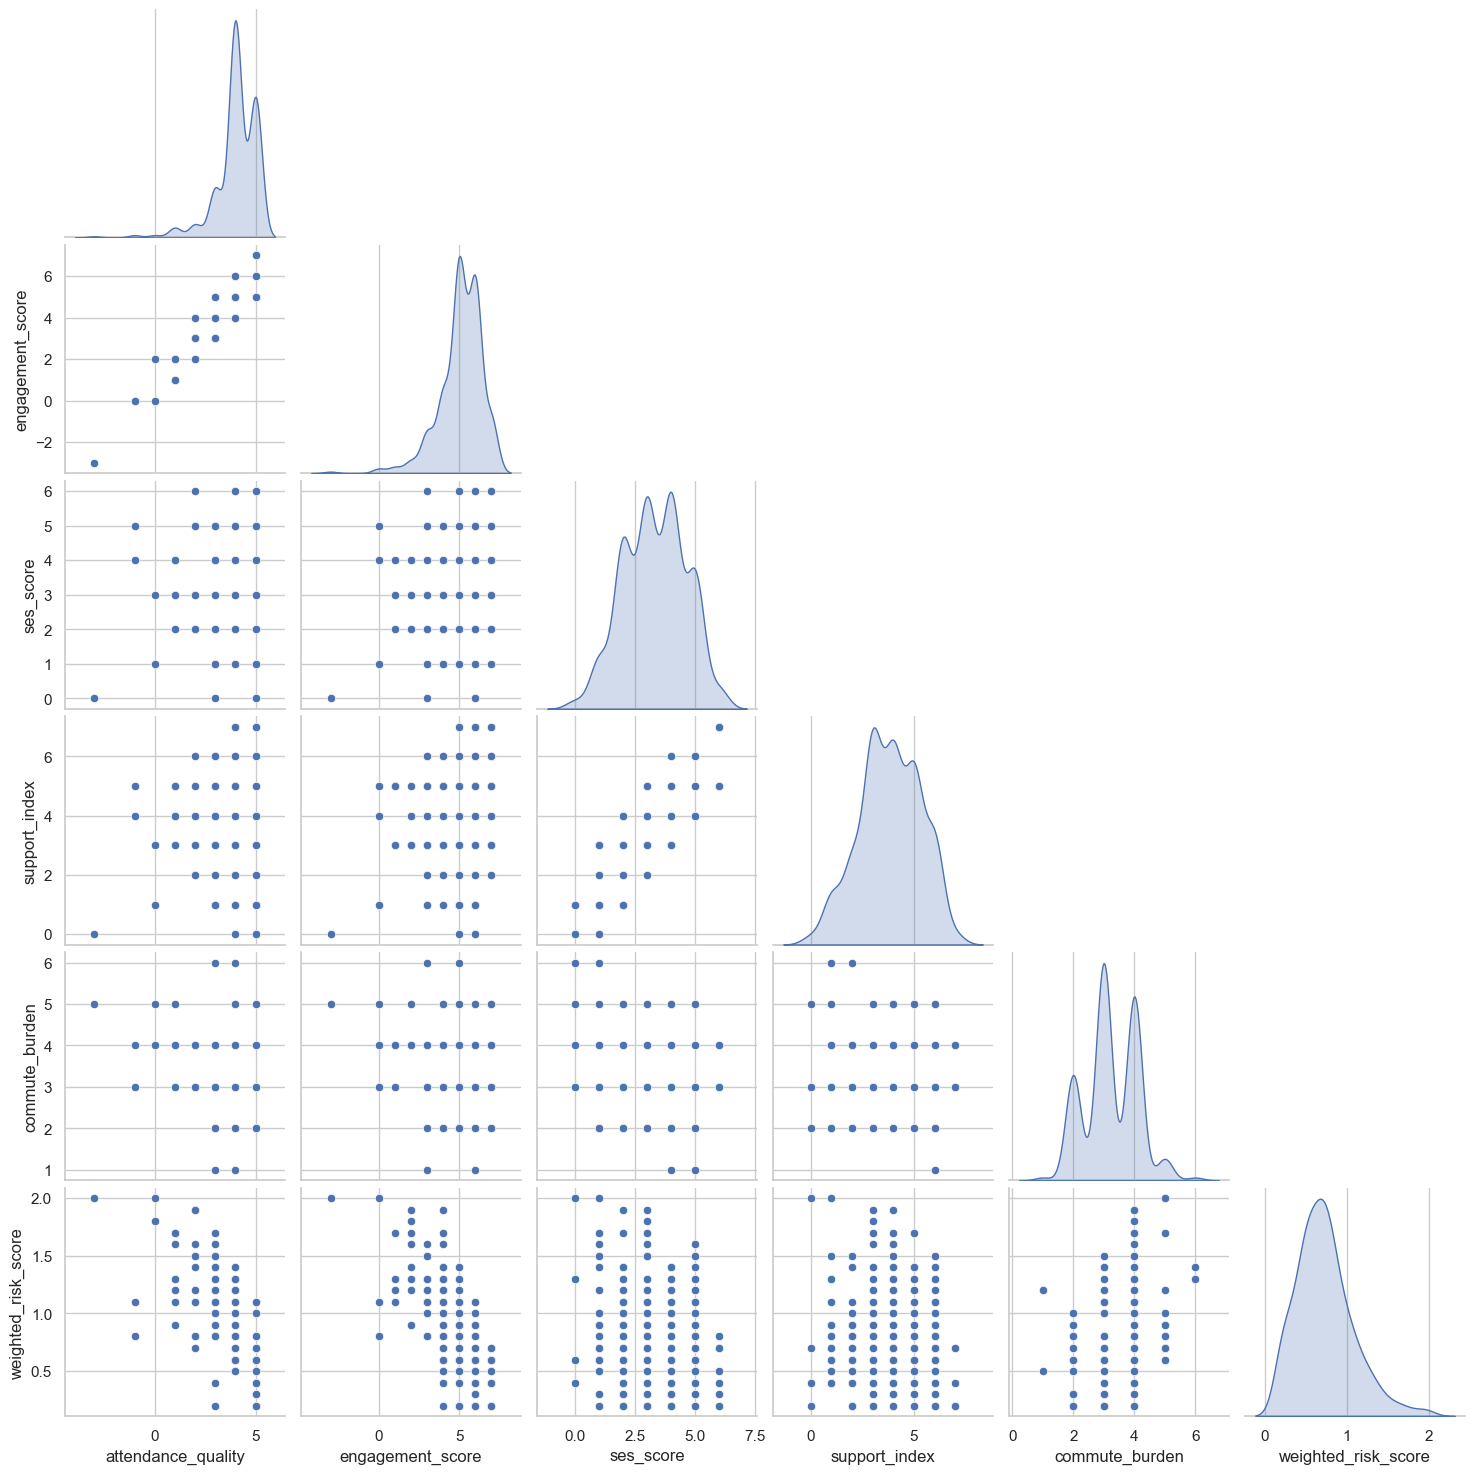

In [8]:
sns.pairplot(X_cluster, diag_kind='kde', corner=True, palette='Set3')

plt.show()

Pairwise plots help reveal separability and non-linear relationships between features.

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

Standardizes features so KMeans distance calculations are on comparable scales.

### Elbow method

find best number of cluster

In [10]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Computes inertia across $k$ to support the elbow method selection.

### Plot Elbow

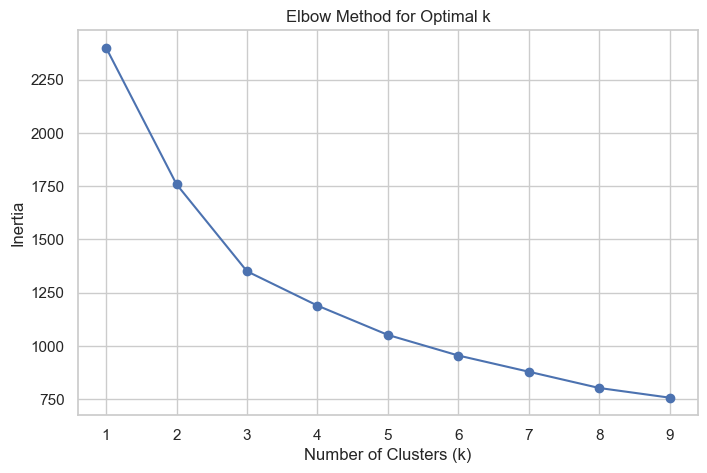

In [11]:
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')   
plt.show()

Elbow plot visualizes diminishing returns as $k$ increases.

### Silhouette Score

In [12]:
sil_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    sil_scores.append(score)

Computes silhouette scores for $k=2$ to $9$ to assess cluster separation quality.

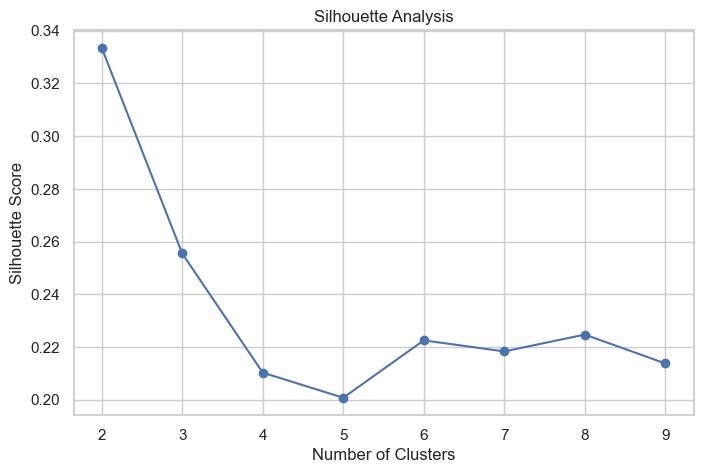

In [13]:
plt.plot(K, sil_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

Silhouette plot highlights which $k$ yields better separation (higher is better).

### Train final KMeans

Usually choose k = 3

In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

encoded_df['cluster'] = kmeans.fit_predict(X_scaled)

Fits final KMeans with $k=3$ and assigns each student to a cluster.

In [15]:
encoded_df['cluster'].value_counts()

cluster
1    201
0    144
2     55
Name: count, dtype: int64

Shows the number of students in each cluster.

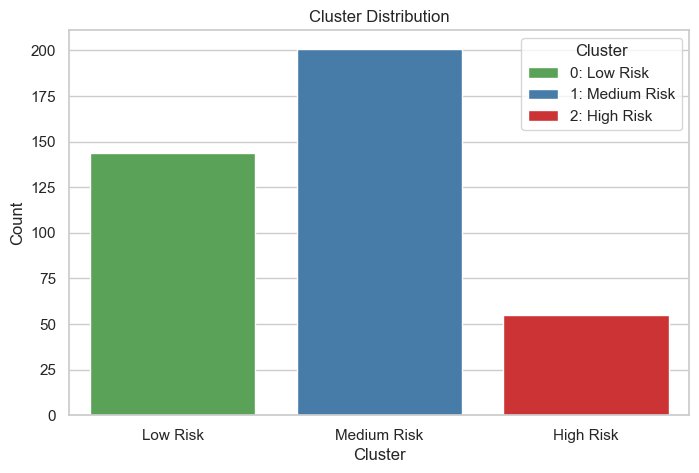

In [16]:
legend_labels = {
    0: '0: Low Risk',
    1: '1: Medium Risk',
    2: '2: High Risk'
}

x_labels = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
}

level_risk_palette = {
    '0': sns.color_palette("Set1")[2],
    '1': sns.color_palette("Set1")[1],
    '2': sns.color_palette("Set1")[0]
}

sns.countplot(x='cluster', data=encoded_df, palette=level_risk_palette)
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(ticks=[0,1,2], labels=[x_labels[i] for i in range(3)])
plt.legend(title='Cluster', labels=[legend_labels[i] for i in range(3)])
plt.show()

Visualizes the cluster size distribution and maps clusters to risk labels.

### PCA Cluster Visualization

Reduce to 2 dimensions.

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [18]:
pca_df = pd.DataFrame()

pca_df['PCA1'] = X_pca[:,0]
pca_df['PCA2'] = X_pca[:,1]

pca_df['cluster'] = encoded_df['cluster']

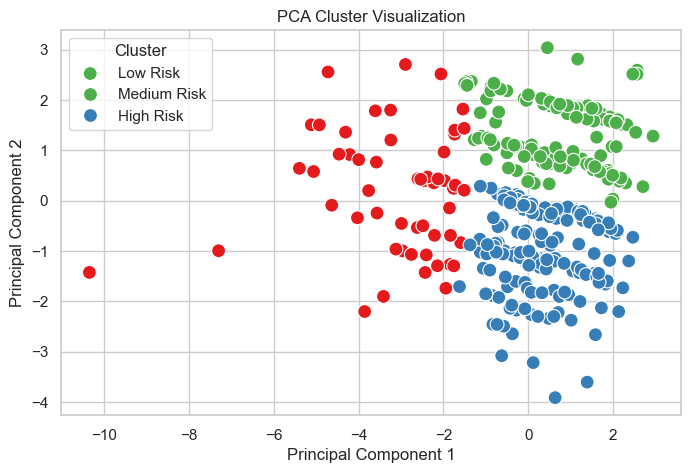

In [19]:

level_risk_palette = {
    0: sns.color_palette("Set1")[2],
    1: sns.color_palette("Set1")[1],
    2: sns.color_palette("Set1")[0]
}

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette=level_risk_palette,
    data=pca_df,
    s=100
)

plt.title("PCA Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster', labels=[x_labels[i] for i in range(3)])
plt.show()

### Cluster Mean Heatmap

In [20]:
cluster_means = encoded_df.groupby('cluster')[cluster_features].mean()

cluster_means

,attendance_quality,engagement_score,ses_score,support_index,commute_burden,weighted_risk_score
cluster,,,,,,
0,4.270833,5.423611,4.541667,5.305556,3.229167,0.653472
1,4.348259,5.462687,2.582090,2.875622,3.069652,0.623881
2,2.163636,2.763636,2.781818,3.472727,3.836364,1.298182


Calculates mean feature values for each cluster to profile risk groups.

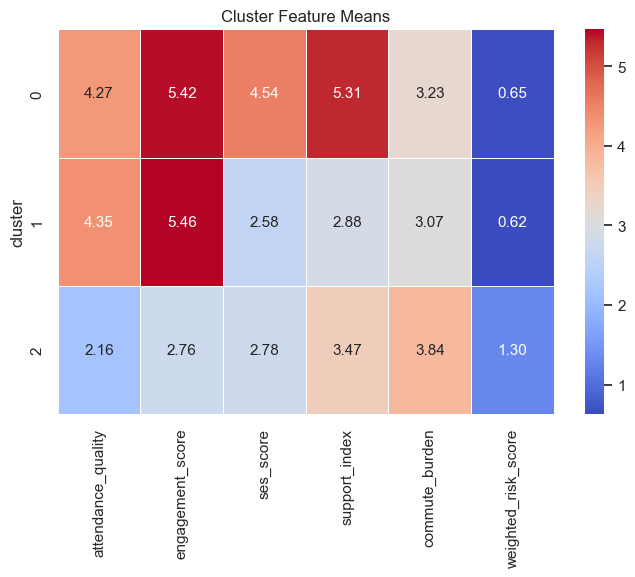

In [21]:
sns.heatmap(
    cluster_means,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Cluster Feature Means")
plt.show()

In [22]:
labels = cluster_features

num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

angles += angles[:1]

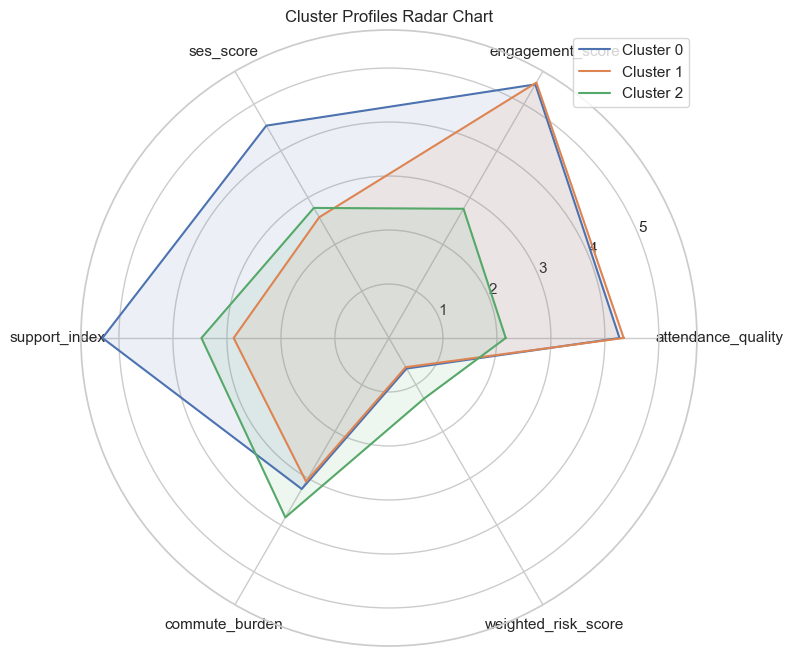

In [23]:
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for i in cluster_means.index:
    
    values = cluster_means.loc[i].tolist()
    values += values[:1]
    
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Cluster Profiles Radar Chart")
plt.legend()
plt.show()

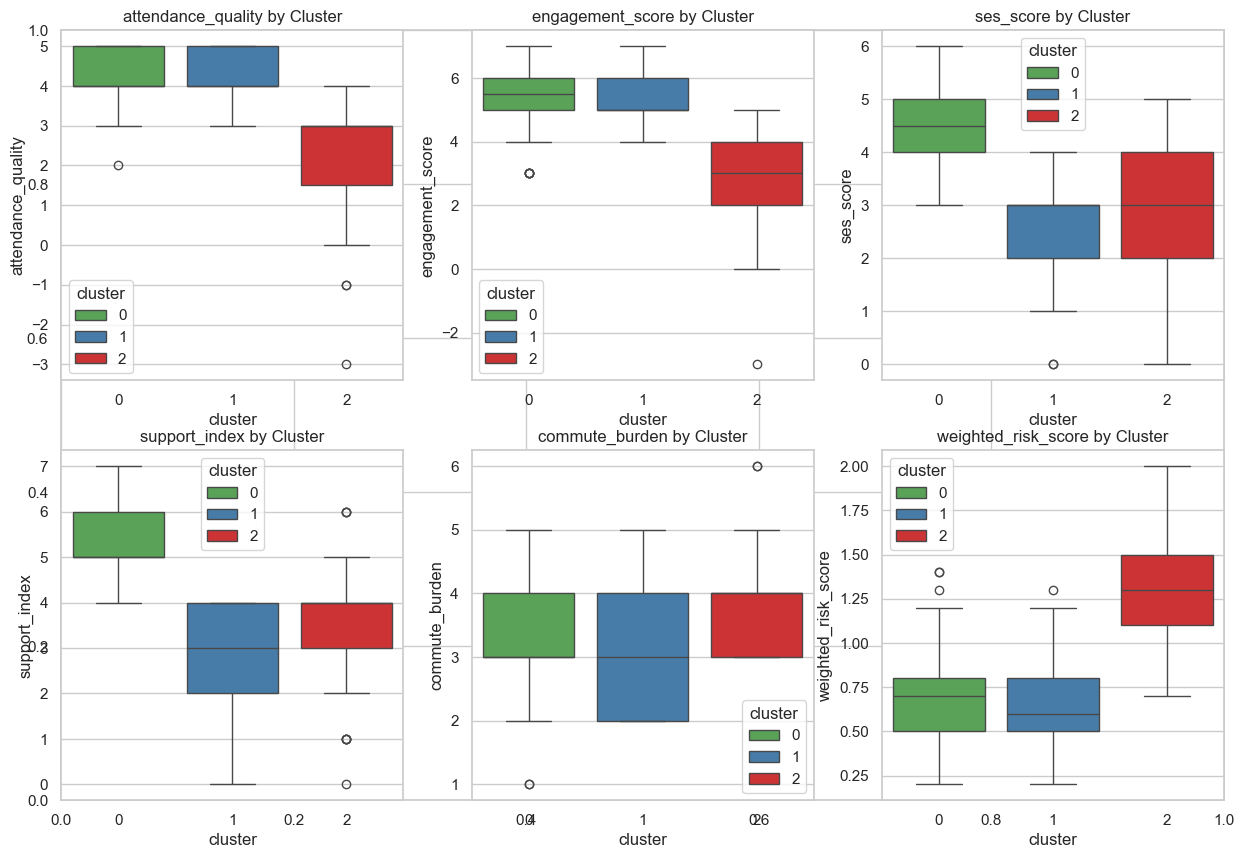

In [24]:
plt.subplots(figsize=(15,10))
for feature in cluster_features:

    plt.subplot(2, 3,  cluster_features.index(feature) + 1)
    sns.boxplot(
        x='cluster',
        y=feature,
        data=encoded_df,
        hue='cluster',
        palette=level_risk_palette,
    )

    plt.title(f'{feature} by Cluster')

plt.show()

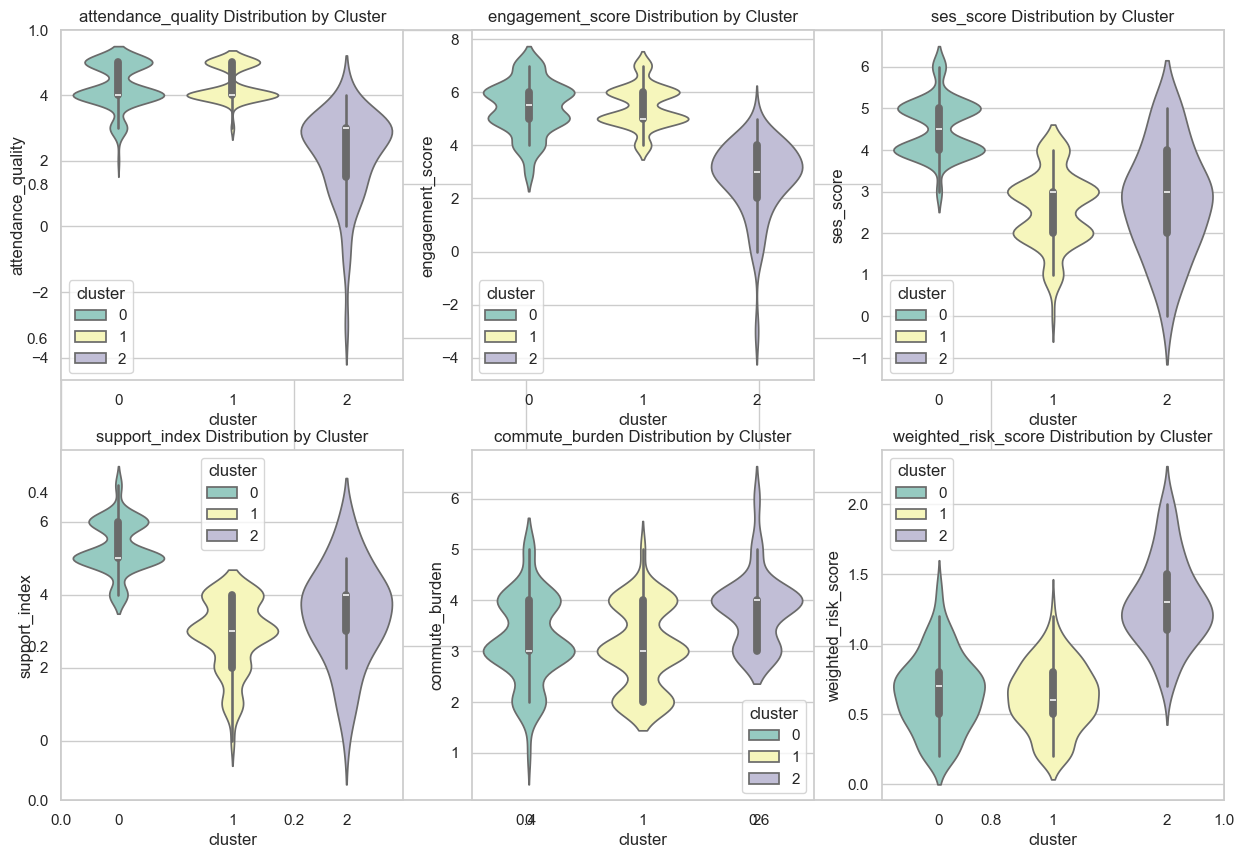

In [25]:

plt.subplots(figsize=(15,10))
for feature in cluster_features:

    plt.subplot(2, 3, cluster_features.index(feature) + 1)

    sns.violinplot(
        x='cluster',
        y=feature,
        data=encoded_df,
        inner='box',
        hue='cluster',
        palette="Set3"
    )

    plt.title(f'{feature} Distribution by Cluster')
plt.tight_layout
plt.show()

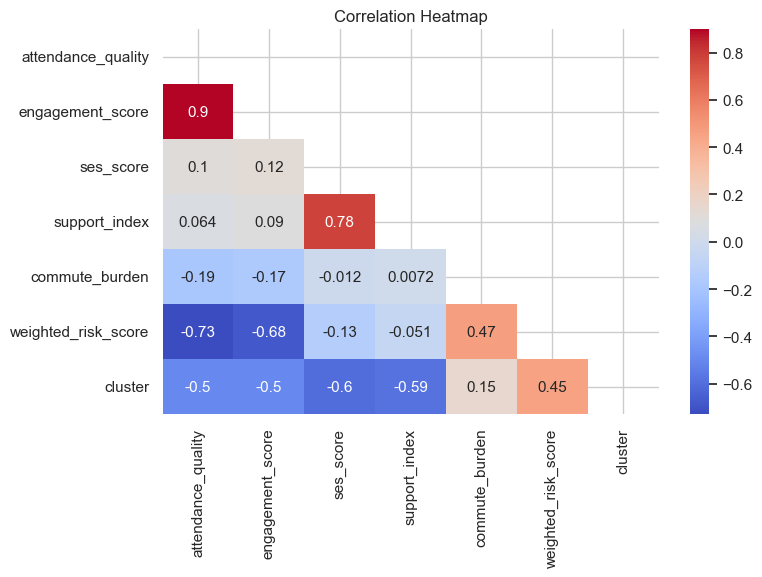

In [26]:
corr_df = encoded_df[cluster_features + ['cluster']]

mask = np.triu(
    np.ones_like(corr_df.corr(), dtype=bool)
)

sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', mask=mask)
plt.title("Correlation Heatmap")
plt.show()

Correlation heatmap including `cluster` shows which features align with cluster labels.

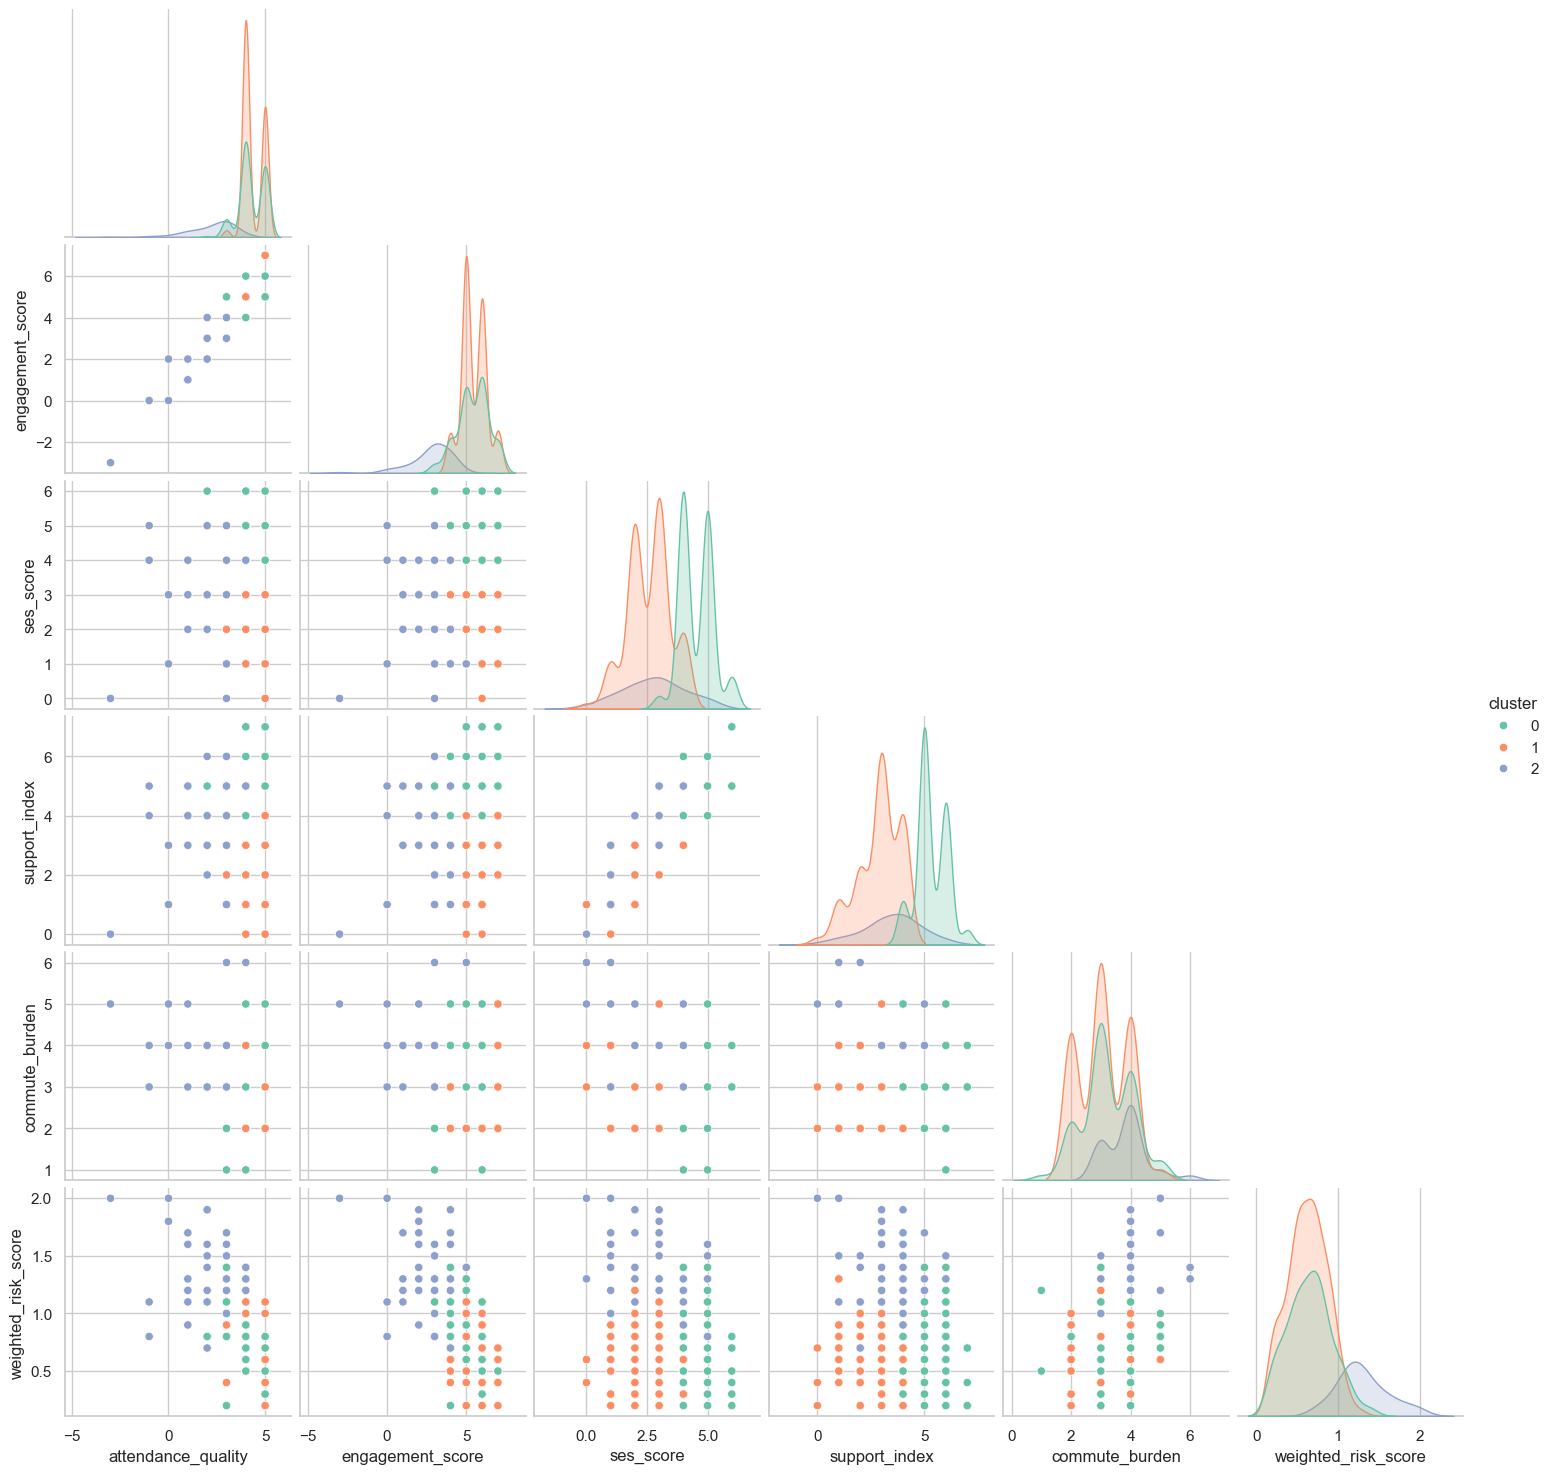

In [27]:
sns.pairplot(encoded_df[cluster_features + ['cluster']], hue='cluster', corner=True, palette='Set2')
plt.show()